# !!!!!!NOTE!!!!!

### USING Chefer et al. 2021: https://arxiv.org/abs/2012.09838

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

from baselines.ViT.ViT_explanation_generator import LRP
import Simple_ViT.simple_vit_lrp as svitl

import importlib
# When you need to reload the module after an update
importlib.reload(svitl)

import getpass
myname = getpass.getuser()

import pandas as pd

import operator
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
from lxt.core import Composite
import lxt.functional as lf
import lxt.modules as lm
import lxt.rules as rules

# import open_clip
# import open_clip.transformer
from openclip_ViT import transformer
from PIL import Image
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules
from zennit.image import imgify

# Data and Compute Prep:

In [2]:
doDask = False
if doDask:
    print('...setting up dask client...')
    if 'client' in locals():
        client.shutdown()
        print('...shutdown client...')
    else:
        print('client does not exist yet')

    # ### ++++++ dask NCAR client: 
    from distributed import Client
    from dask_jobqueue import PBSCluster
    project_num = 'P03010039' #'P03010039' #what project key do you have? 
    
    cluster = PBSCluster(account=project_num,
                         walltime='12:00:00',
                         cores=1,
                         memory='40GB',
                         shared_temp_directory='/glade/derecho/scratch/kjmayer/tmp',
                         queue='casper')
    cluster.scale(jobs=40)
    client = Client(cluster)
    print(client) 

print(torch.cuda.is_available())

def set_gpu(gpu_id):
    os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
    
gpu_id=0

# if gpu_id >= 0:
#     device = "cuda"
#     set_gpu(gpu_id)
#     print('device available :', torch.cuda.is_available())
#     print('device count: ', torch.cuda.device_count())
#     print('current device: ',torch.cuda.current_device())
#     print('device name: ',torch.cuda.get_device_name())
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# else:
device = torch.device('cuda')


#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

print('using device: ', device)

True
NVIDIA A100-SXM4-80GB
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB
using device:  cuda


# LOAD & PREP DATA

## Load the Data

In [3]:
myname = 'kjmayer'
dirout = f'/glade/derecho/scratch/{myname}/TOMSensoDS/'
# Check if the directory exists
if not os.path.exists(dirout):
    # Create the directory
    os.makedirs(dirout)
    print(f"Directory {dirout} created.")
else:
    print(f"Directory {dirout} already exists.")

# Old files:
# DSmean_sst_anom = xr.open_dataset(os.path.join(dirout, 'SST_CESM2_PI_Chunked.nc'))
# DSmean_trefht_anom_roll = xr.open_dataset(os.path.join(dirout, 'SST_CESM2_PI_Chunked.nc'))
# DSmean_trefht_anom_roll = xr.open_dataset(os.path.join(dirout, 'TREFHT_CESM2_PI_Chunked.nc'))
# DSmean_sst_anom['time'] = DSmean_trefht_anom_roll['time']

DSmean_sst_anom = xr.open_dataset(os.path.join(dirout, 'SST_CESM2_PI_Chunked_Rolled.nc')) #30 day centered rolling mean
print('...done loading SST...')

# 2m temperature:
# finame = 'TREFHT_CESM2_PI_Chunked.nc'
# var_name = 'TREHT'
# rolled SST: 30 day centered rolling mean
finame = 'SST_CESM2_PI_Chunked_Rolled.nc'
var_name = 'SST'
DSmean_trefht_anom_roll = xr.open_dataset(os.path.join(dirout, finame)) 
print('...done loading TREFHT...')

if doDask: 
    DSmean_sst_anom = DSmean_sst_anom.chunk({'time':5})
    DSmean_trefht_anom_roll = DSmean_trefht_anom_roll.chunk({'time':5})
    DSmean_sst_anom = DSmean_sst_anom.chunk({'time':5})

Directory /glade/derecho/scratch/kjmayer/TOMSensoDS/ already exists.
...done loading SST...
...done loading TREFHT...


## Slice spatially and temporally

In [4]:
# NOTE: adding 30 because of 30 day rolling mean on X and Y
lead_time = 30 + 30 

# SUBSET X TO 5S-5N & SLICE FOR LEAD
DSmean_sst_anom_lag = DSmean_sst_anom['SST'].isel(time=slice(0,-lead_time),
                                                  lat=slice(90,102))

# SUBSET Y TO REGION (off coast of southern CA) & SLICE FOR LEAD
# (32-36N, 230-235E)
if var_name == 'TREHT':
    ilat, flat = 15, 27 #129, 135
    ilon, flon = 28, 37 #184, 189
else:
    ilat, flat = 138, 150
    ilon, flon = 188, 197
DSmean_trefht_anom_roll_lag = DSmean_trefht_anom_roll[var_name].isel(time=slice(lead_time,len(DSmean_trefht_anom_roll['time'])),
                                                                 lat=slice(ilat,flat),
                                                                 lon=slice(ilon,flon))
print(DSmean_trefht_anom_roll_lag.lat, DSmean_trefht_anom_roll_lag.lon)
# DSmean_trefht_anom_roll_lag = DSmean_trefht_anom_roll['TREHT'].isel(time=slice(lead_time,len(DSmean_trefht_anom_roll['time'])))

<xarray.DataArray 'lat' (lat: 12)>
array([40.052356, 40.994764, 41.937173, 42.879581, 43.82199 , 44.764398,
       45.706806, 46.649215, 47.591623, 48.534031, 49.47644 , 50.418848])
Coordinates:
  * lat      (lat) float64 40.05 40.99 41.94 42.88 ... 47.59 48.53 49.48 50.42
Attributes:
    long_name:  latitude
    units:      degrees_north <xarray.DataArray 'lon' (lon: 9)>
array([235.  , 236.25, 237.5 , 238.75, 240.  , 241.25, 242.5 , 243.75, 245.  ])
Coordinates:
  * lon      (lon) float64 235.0 236.2 237.5 238.8 240.0 241.2 242.5 243.8 245.0
Attributes:
    long_name:  longitude
    units:      degrees_east


## Let's Lag this Bad Baby

In [5]:
%%time
print('here we go')
##################################################
##### 1700 - 2000
##################################################

date_range = pd.date_range(start='1700-01-01', end='2000-01-01')
# Filter out February 29th
filtered_date_range = date_range[~((date_range.month == 2) & (date_range.day == 29))]\
# Display the filtered date range
end_date_300 = len(filtered_date_range)

print('...gather training...')
y_train = DSmean_trefht_anom_roll_lag.isel(time=slice(0,end_date_300-1))
y_train_anom = y_train.groupby('time.dayofyear') - y_train.groupby('time.dayofyear').mean()
y_train_anom_mean = np.mean(y_train_anom,axis=(1,2))
y_train_cat = xr.where(y_train_anom_mean > 0, x=1, y=0)


x_train = DSmean_sst_anom_lag.isel(time=slice(0,end_date_300-1))
x_train_anom = x_train.groupby('time.dayofyear') - x_train.groupby('time.dayofyear').mean()

##################################################
##### 2000 - 2100
##################################################
date_range = pd.date_range(start='1700-01-01', end='2101-01-01')
# Filter out February 29th
filtered_date_range = date_range[~((date_range.month == 2) & (date_range.day == 29))]\
# Display the filtered date range
indy_val_s = int(np.where(filtered_date_range == '2000-01-01')[0])
indy_val_e = int(np.where(filtered_date_range == '2100-01-01')[0])

print('...gather validation...')
y_val = DSmean_trefht_anom_roll_lag.isel(time=slice(indy_val_s,indy_val_e))
y_val_anom = y_val.groupby('time.dayofyear') - y_val.groupby('time.dayofyear').mean()
y_val_anom_mean = np.mean(y_train_anom,axis=(1,2))
y_val_cat = xr.where(y_val_anom_mean > 0, x=1, y=0)

x_val = DSmean_sst_anom_lag.isel(time=slice(indy_val_s,indy_val_e))
x_val_anom = x_val.groupby('time.dayofyear') - x_val.groupby('time.dayofyear').mean()

##################################################
##### 2000 - 2100
##################################################

date_range = pd.date_range(start='1700-01-01', end='2201-01-01')
# Filter out February 29th
filtered_date_range = date_range[~((date_range.month == 2) & (date_range.day == 29))]\
# Display the filtered date range
indy_test_s = int(np.where(filtered_date_range == '2100-01-01')[0])
indy_test_e = int(np.where(filtered_date_range == '2200-01-01')[0])

print('...gather testing...')
y_test = DSmean_trefht_anom_roll_lag.isel(time=slice(indy_test_s,indy_test_e))
y_test_anom = y_test.groupby('time.dayofyear') - y_test.groupby('time.dayofyear').mean()
y_test_anom_mean = np.mean(y_train_anom,axis=(1,2))
y_test_cat = xr.where(y_test_anom_mean > 0, x=1, y=0)

x_test = DSmean_sst_anom_lag.isel(time=slice(indy_test_s,indy_test_e))
x_test_anom = x_test.groupby('time.dayofyear') - x_test.groupby('time.dayofyear').mean()
print('done')

here we go
...gather training...


<timed exec>:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
<timed exec>:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


...gather validation...


<timed exec>:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
<timed exec>:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


...gather testing...
done
CPU times: user 14.3 s, sys: 2.61 s, total: 16.9 s
Wall time: 18.5 s


## Subset for DJF

In [6]:
ixtrain_DJF = np.where(x_train_anom['time.month'].isin([12,1,2]))[0]
ixval_DJF = np.where(x_val_anom['time.month'].isin([12,1,2]))[0]
ixtest_DJF = np.where(x_test_anom['time.month'].isin([12,1,2]))[0]

x_train_anom_DJF = x_train_anom[ixtrain_DJF]
x_val_anom_DJF = x_val_anom[ixval_DJF]
x_test_anom_DJF = x_test_anom[ixtest_DJF]

y_train_anom_DJF = y_train_cat[ixtrain_DJF]
y_val_anom_DJF = y_val_cat[ixval_DJF]
y_test_anom_DJF = y_test_cat[ixtest_DJF]

## Convert to numpy

In [7]:
%%time
np_arr_x_train_anom = np.array(x_train_anom_DJF)
np_arr_x_val_anom = np.array(x_val_anom_DJF) 
np_arr_y_train_anom = np.array(y_train_anom_DJF)
np_arr_y_val_anom = np.array(y_val_anom_DJF)

CPU times: user 24.4 ms, sys: 36.1 ms, total: 60.4 ms
Wall time: 60.7 ms


## look at ENSO and find Y region

In [8]:
%%time
#Find a good location to predict
# enso = x_train_anom_DJF.sel(lat=slice(-5,5),lon=slice(190,240)).mean(('lat','lon'))
# nino = enso.where(enso >= 2, drop=True).load()
# nina = enso.where(enso <= -2, drop=True).load()
# notenso = enso.where((enso > -2) & (enso < 2), drop=True).load()
# notnino = enso.where(enso < 2, drop=True).load()

# corrs = np.zeros(shape=(42,41))
# for ilat in np.arange(0,len(y_train_anom_DJF.lat)):
#     for ilon in np.arange(0,len(y_train_anom_DJF.lon)):
#         corrs[ilat,ilon] = np.corrcoef(enso,y_train_anom_DJF[:, ilat, ilon])[0,1]

# plt.pcolormesh(corrs,cmap='RdBu_r',vmin=-.5,vmax=.5)
# plt.colorbar()
# plt.show()

# Define & Check Predictand Point (do not delete this bad boy; vital for exsistence)
# enso = x_train_anom_DJF.sel(lat=slice(-5,5),lon=slice(190,240)).mean(('lat','lon'))
# inino = np.where(enso >= 2)[0]
# inina = np.where(enso <= -2)[0]
# inotenso = np.where((enso > -2) & (enso < 2))[0]

# change these and make sure the Y loading doesnt already subset to a region
# ilat, flat = 129, 135
# ilon, flon = 184, 189
# yall = y_train_anom_DJF[:, ilat:flat, ilon:flon].mean(('lat','lon')).isel(time=inotenso)
# ynino = y_train_anom_DJF[:, ilat:flat, ilon:flon].mean(('lat','lon')).isel(time=inino)

# plt.hist(yall,density=True,bins=50)
# plt.hist(ynino,density=True,alpha=0.5,bins=50)
# plt.show()

# plt.pcolormesh(np_arr_x_train_anom[0])
# plt.show()
# plt.pcolormesh(np_arr_y_train_anom[0])
# plt.show()

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 3.81 µs


# TRAINING

## Data Loader

In [9]:
class SpatialDataset(Dataset):
    def __init__(self, X, y):
        randi = np.random.choice(range(np.shape(X)[0]),size=np.shape(X)[0])
        self.X = torch.nan_to_num(torch.tensor(X[randi], dtype=torch.float32))
        self.y = torch.tensor(y[randi], dtype=torch.float32) #of the coast NW NA

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx].unsqueeze(0)

## Model

In [50]:
BATCH_SIZE = 4
IN_CHANNELS = 1
OUTPUT_DIM = 1
PATCH_SIZE = 2
WIDTH, LAYERS = 12, 4
HEADS = 2
MLP_RATIO = 2
INPUT_SIZE = np.shape(np_arr_x_train_anom)
LR = 0.001
PATIENCE = 3

model = svitl.VisionTransformer(
        image_lr = INPUT_SIZE[1],
        image_ud = INPUT_SIZE[2],
        patch_size = PATCH_SIZE,
        num_classes = OUTPUT_DIM,
        in_chans = IN_CHANNELS,
        embed_dim = 4,
        depth = LAYERS,
        num_heads = HEADS,
        mlp_ratio = MLP_RATIO,
    ).to(device)


criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=PATIENCE, verbose=True)

train_dataset = SpatialDataset(np_arr_x_train_anom, np_arr_y_train_anom )
val_dataset = SpatialDataset(np_arr_x_val_anom, np_arr_y_val_anom)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [51]:
model = model.to(device)
num_epochs = 15
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    print(f"Starting Epoch {epoch}")
    nsampsseen = 0
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels) 
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        nsampsseen += inputs.shape[0]
        if nsampsseen > 100000:
            break
    epoch_loss = running_loss / nsampsseen
    print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    acc_val_batch = []
    labels_full = []
    outputs_full = []
    with torch.no_grad():  # In validation phase, we don't need to compute gradients
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs.to(device))
            cat_outputs = (outputs > 0.5).type(torch.int)
            acc_val_batch.append(((labels==cat_outputs).type(torch.int).sum().item())/len(outputs))
            labels_full.append(labels)
            outputs_full.append(outputs)
    # Calculate and print validation accuracy
    acc_tot=torch.mean(torch.tensor(acc_val_batch))
    
    print(f"Accuracy: {acc_tot:.5f}")
    
    if epoch == 0:
        print('...saved first epoch...')
        best_mod = copy.deepcopy(model)
        best_acc = copy.deepcopy(acc_tot)
    elif acc_tot>best_acc:
        print('...saving!...')
        best_mod = copy.deepcopy(model)
        best_acc = copy.deepcopy(acc_tot)
    else:
        print('No improvement in validation accuracy.')
    # Step the scheduler on each epoch
    scheduler.step(acc_tot.item())

Starting Epoch 0
Epoch 0, Loss: 0.5984
Accuracy: 0.54489
...saved first epoch...
Starting Epoch 1
Epoch 1, Loss: 0.5877
Accuracy: 0.54089
No improvement in validation accuracy.
Starting Epoch 2


KeyboardInterrupt: 

In [52]:
labels_full = []
outputs_full = []
acc_val_batch = []
# inputs_all=[]
with torch.no_grad():  # In validation phase, we don't need to compute gradients
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        # print(inputs.grad)
        outputs = best_mod(inputs.to(device))
        cat_outputs = (outputs > 0.5).type(torch.int)
        acc_val_batch.append(((labels==cat_outputs).type(torch.int).sum().item())/len(outputs))
        labels_full.append(labels)
        outputs_full.append(outputs)

        # inputs_all.append(inputs)

acc_tot=torch.mean(torch.tensor(acc_val_batch))
acc_tot

tensor(0.5449)

## LRP

In [ ]:
# newmodel = torch.nn.Sequential(*(list(best_mod.children())[:-2]))
# newmodel.children

In [22]:
np.where(transformer_attribution != 0)

(array([], dtype=int64), array([], dtype=int64))

In [33]:
best_mod(torch.tensor(np_arr_x_val_anom[10]).unsqueeze(dim=0).unsqueeze(dim=0).to(device))

tensor([[0.2903]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [54]:
np.sum(transformer_attribution)

0.0

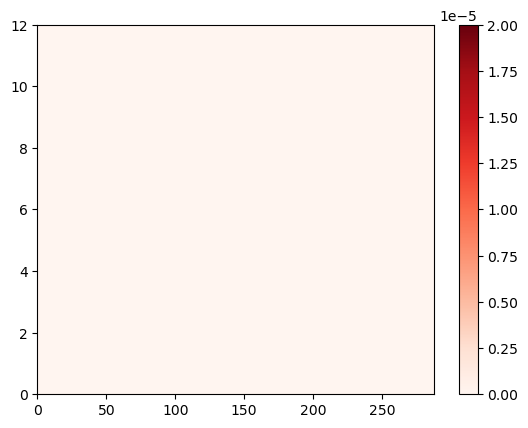

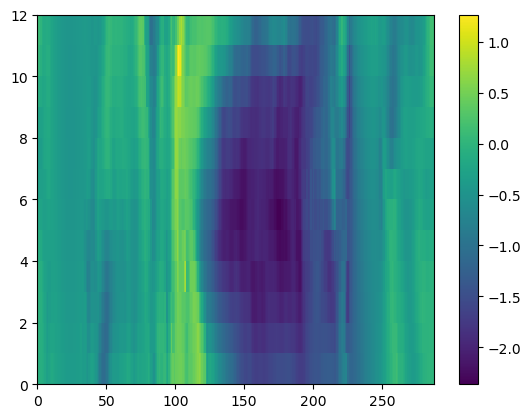

In [53]:
x = torch.nan_to_num(torch.tensor(np_arr_x_val_anom[50], dtype=torch.float32).unsqueeze(0).unsqueeze(0))

attribution_generator = LRP(best_mod)
transformer_attribution = attribution_generator.generate_LRP(x.to(device), method="transformer_attribution", index=0).detach()
transformer_attribution = transformer_attribution.reshape(1, 1, 6, 144)
transformer_attribution = torch.nn.functional.interpolate(transformer_attribution, scale_factor=2, mode='bilinear')
transformer_attribution = transformer_attribution.reshape(12, 288).data.cpu().numpy()

plt.pcolormesh(transformer_attribution.squeeze(),cmap='Reds', vmin=0, vmax=2*1e-5)
plt.colorbar()
plt.show()

plt.pcolormesh(x.squeeze().cpu())
plt.colorbar()
plt.show()

In [ ]:
labels_list = torch.cat(labels_full).cpu()
outputs_list = torch.cat(outputs_full).cpu()

In [ ]:
labels = labels.to(device)
outputs = model(inputs.to(device))

In [ ]:
outputs.shape

In [ ]:
# import gc
# gc.collect()
# torch.cuda.empty_cache()